Clases: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Epoch 1: Train Loss=0.5769, Val Loss=0.2586, Train Acc=0.7927, Val Acc=0.9083
Epoch 2: Train Loss=0.2497, Val Loss=0.2467, Train Acc=0.9136, Val Acc=0.9229
Epoch 3: Train Loss=0.2102, Val Loss=0.1840, Train Acc=0.9269, Val Acc=0.9312
Epoch 4: Train Loss=0.1571, Val Loss=0.1093, Train Acc=0.9439, Val Acc=0.9633
Epoch 5: Train Loss=0.1301, Val Loss=0.0689, Train Acc=0.9545, Val Acc=0.9780
Epoch 6: Train Loss=0.0947, Val Loss=0.1144, Train Acc=0.9688, Val Acc=0.9615
Epoch 7: Train Loss=0.0947, Val Loss=0.0889, Train Acc=0.9681, Val Acc=0.9725
Epoch 8: Train Loss=0.0898, Val Loss=0.0725, Train Acc=0.9695, Val Acc=0.9725
Epoch 9: Train Loss=0.0558, Val Loss=0.0744, Train Acc=0.9807, Val Acc=0.9734
Epoch 10: Train Loss=0.0570, Val Loss=0.0868, Train Acc=0.9807, Val Acc=0.9670
Early stopping activado.

Reporte de Clasificación:
               precision    recall  f1-score   support

  fresh

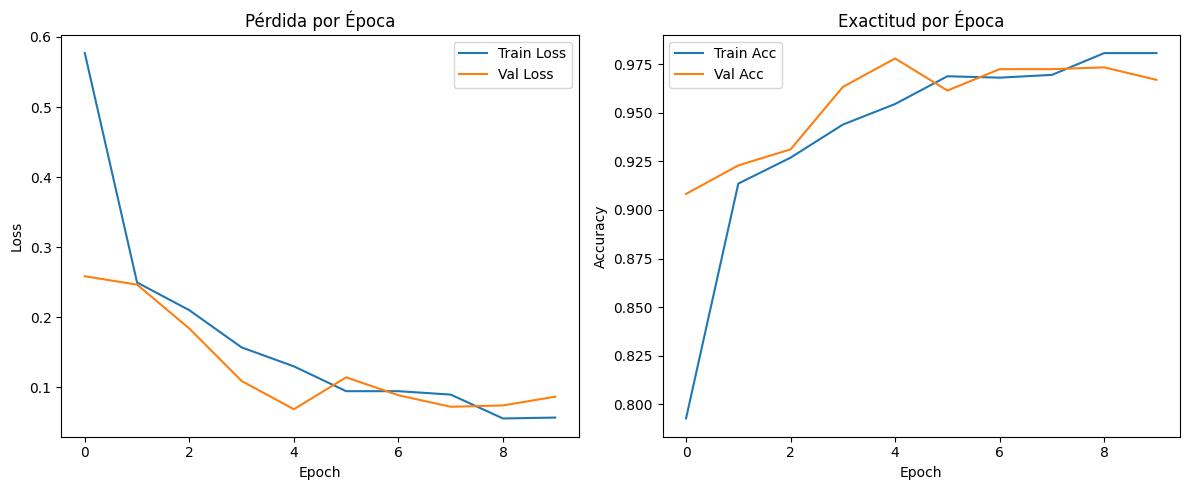

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np

# ============================
# 1. Preprocesamiento y Carga de Datos
# ============================
# Transformaciones
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# Ruta al dataset (ajusta según donde esté)
dataset_root = '../data'

# Dataset con carpetas por clase
train_dataset_full = datasets.ImageFolder(root=f'{dataset_root}/train', transform=train_transforms)
test_dataset = datasets.ImageFolder(root=f'{dataset_root}/test', transform=test_transforms)

# Dividir train en train y validación
val_size = int(0.1 * len(train_dataset_full))
train_size = len(train_dataset_full) - val_size
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])
val_dataset.dataset.transform = test_transforms  # sin data augmentation en validación

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Ver clases
class_names = train_dataset_full.classes
print("Clases:", class_names)

# ============================
# 2. Modelo CNN
# ============================
class FruitClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super(FruitClassifierCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

num_classes = len(class_names)
model = FruitClassifierCNN(num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ============================
# 3. Entrenamiento
# ============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 25
patience = 5
best_val_loss = float('inf')
patience_counter = 0

train_losses, val_losses = [], []
train_acc_list, val_acc_list = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
    
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / len(train_loader.dataset)
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)

    # Validación
    model.eval()
    val_loss = 0.0
    val_correct = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping activado.")
            break

# ============================
# 4. Evaluación Final
# ============================
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nReporte de Clasificación:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ============================
# 5. Visualización
# ============================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Pérdida por Época")

plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Exactitud por Época")

plt.tight_layout()
plt.show()


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np
import copy
import time

# ============================
# 1. Preprocesamiento y Carga de Datos
# ============================
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# Define la ruta del dataset (ajusta según corresponda)
dataset_root = '../data'

# Cargar dataset utilizando ImageFolder
train_dataset_full = datasets.ImageFolder(root=f'{dataset_root}/train', transform=train_transforms)
test_dataset = datasets.ImageFolder(root=f'{dataset_root}/test', transform=test_transforms)

# Dividir el conjunto de entrenamiento en train y validación
val_size = int(0.1 * len(train_dataset_full))
train_size = len(train_dataset_full) - val_size
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])
val_dataset.dataset.transform = test_transforms  # Sin data augmentation en validación

# Número de clases
class_names = train_dataset_full.classes
num_classes = len(class_names)
print("Clases:", class_names)

# ============================
# 2. Definición del Modelo CNN
# ============================
class FruitClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super(FruitClassifierCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128x128 -> 64x64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64x64 -> 32x32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 32x32 -> 16x16
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# ============================
# 3. Función para Entrenar el Modelo
# ============================
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10, patience=3):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / len(train_loader.dataset)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        # Evaluación en validación
        model.eval()
        val_loss = 0.0
        val_correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs}: Train loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
        
        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping activado")
                break

    model.load_state_dict(best_model_wts)
    return model, history

# ============================
# 4. Hyperparameter Tuning
# ============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Definir grilla de hiperparámetros a probar
learning_rates = [0.001, 0.0005]
batch_sizes = [16, 32]
num_epochs = 10  # Para tuning, puedes reducir las épocas

results = {}  # Para almacenar resultados de cada combinación

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\nEntrenando con learning rate = {lr} y batch size = {bs}")
        # Crear DataLoaders con el batch size actual
        train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        val_loader   = DataLoader(val_dataset, batch_size=bs, shuffle=False)
        
        # Instanciar un nuevo modelo para esta combinación
        model = FruitClassifierCNN(num_classes)
        model.to(device)
        
        # Definir criterio y optimizador
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        inicio = time.time()
        model, history = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=num_epochs, patience=3)
        duracion = time.time() - inicio
        
        # Evaluar en conjunto de validación
        best_val_acc = max(history['val_acc'])
        results[(lr, bs)] = {'history': history, 'best_val_acc': best_val_acc, 'training_time': duracion}
        
        print(f"Resultado para lr={lr}, batch_size={bs}: Mejor Val Acc = {best_val_acc:.4f}, Tiempo de entrenamiento = {duracion:.2f} s")

# Mostrar resumen de resultados
print("\nResumen de Hyperparameter Tuning:")
for (lr, bs), result in results.items():
    print(f"Learning Rate: {lr}, Batch Size: {bs}, Mejor Val Acc: {result['best_val_acc']:.4f}, Tiempo: {result['training_time']:.2f} s")

# ============================
# 5. Evaluación Final con el Mejor Modelo
# ============================
# Se asume que se elige la combinación con mayor accuracy en validación
best_params = max(results, key=lambda x: results[x]['best_val_acc'])
print(f"\nMejor combinación de hiperparámetros: Learning Rate: {best_params[0]}, Batch Size: {best_params[1]}")

# Regenerar DataLoader con el mejor batch_size
train_loader = DataLoader(train_dataset, batch_size=best_params[1], shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=best_params[1], shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=best_params[1], shuffle=False)

# Instanciar y entrenar de nuevo el modelo con la mejor tasa de aprendizaje
model = FruitClassifierCNN(num_classes)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=best_params[0])
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=25, patience=5)

# Evaluar en el conjunto de Test
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nReporte de Clasificación en Test:")
print(classification_report(all_labels, all_preds, target_names=class_names))




Clases: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']

Entrenando con learning rate = 0.001 y batch size = 16
Epoch 1/10: Train loss=0.5178, Train Acc=0.8114, Val loss=0.3126, Val Acc=0.8780
Epoch 2/10: Train loss=0.2378, Train Acc=0.9205, Val loss=0.1942, Val Acc=0.9367
Epoch 3/10: Train loss=0.1976, Train Acc=0.9313, Val loss=0.2185, Val Acc=0.9303
Epoch 4/10: Train loss=0.1508, Train Acc=0.9456, Val loss=0.1216, Val Acc=0.9596
Epoch 5/10: Train loss=0.1140, Train Acc=0.9626, Val loss=0.0801, Val Acc=0.9706
Epoch 6/10: Train loss=0.0840, Train Acc=0.9706, Val loss=0.1383, Val Acc=0.9569
Epoch 7/10: Train loss=0.0835, Train Acc=0.9738, Val loss=0.1343, Val Acc=0.9514
Epoch 8/10: Train loss=0.0785, Train Acc=0.9737, Val loss=0.0828, Val Acc=0.9697
Early stopping activado
Resultado para lr=0.001, batch_size=16: Mejor Val Acc = 0.9706, Tiempo de entrenamiento = 504.95 s

Entrenando con learning rate = 0.001 y batch size = 32
Epoch 1/10: T

In [5]:
torch.save(model.state_dict(), 'modelBasic.pth')